In [2]:
import pandas as pd
import glob, os
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import pandas as pd
import numpy as np
import re
import glob

metric_files = glob.glob("/users/ebrown62/scCODA/sccoda/datasets/results/metrics/driver_metricsN*")

metrics = {}
for f in metric_files:
    N = int(re.search(r"driver_metricsN(\d+)", f).group(1))
    metrics[N] = pd.read_csv(f)



In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

def plot_confusion_matrix(TN, FP, FN, TP, title=None):
    mat = np.array([[1, 0],
                    [0, 1]])

    orange = "#f4b183"
    blue   = "#c9daf8"
    cmap = ListedColormap([blue, orange])

    cm = np.array([[TP, FP],
                   [FN, TN]])
    
    labels = [["TP", "FP"],
              ["FN", "TN"]]
    
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.imshow(mat, cmap=cmap, aspect="equal")

    for i in range(2):
        for j in range(2):
            text = f"{labels[i][j]}\n{cm[i,j]}"
            ax.text(j, i, text,
                    ha="center", va="center",
                    fontsize=24, fontweight="bold", color="black")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Positive", "Negative"], fontsize=16)
    ax.set_xlabel("True", fontsize=20, labelpad=15)

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Positive", "Negative"], fontsize=16)
    ax.set_ylabel("Inferred", fontsize=20, labelpad=15)

    
    ax.set_title(title, fontsize=22, pad=20)

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()


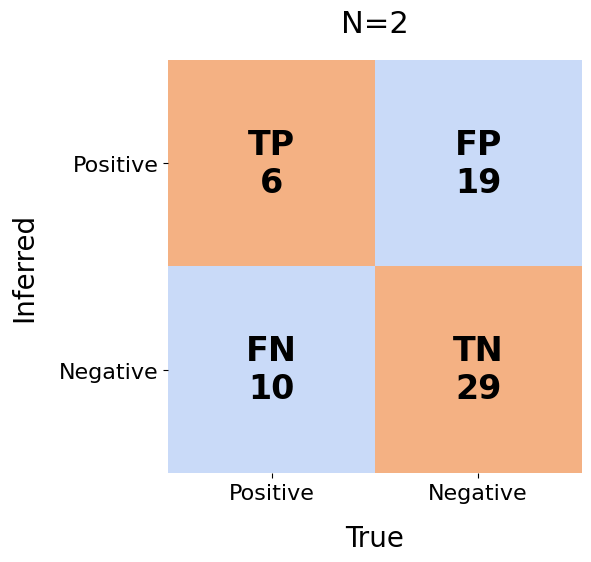

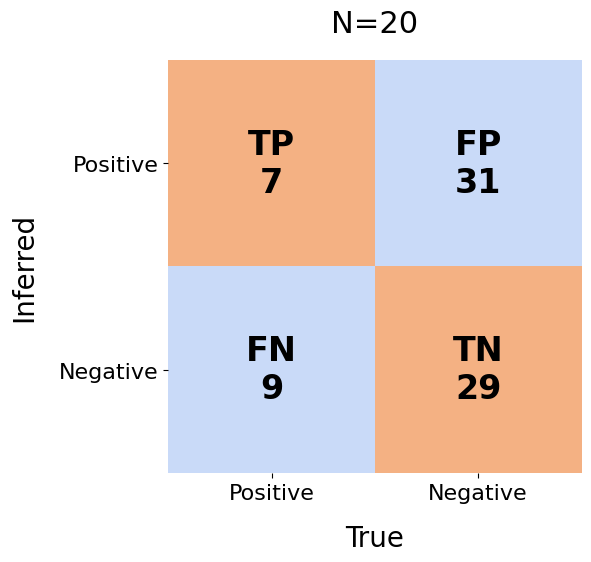

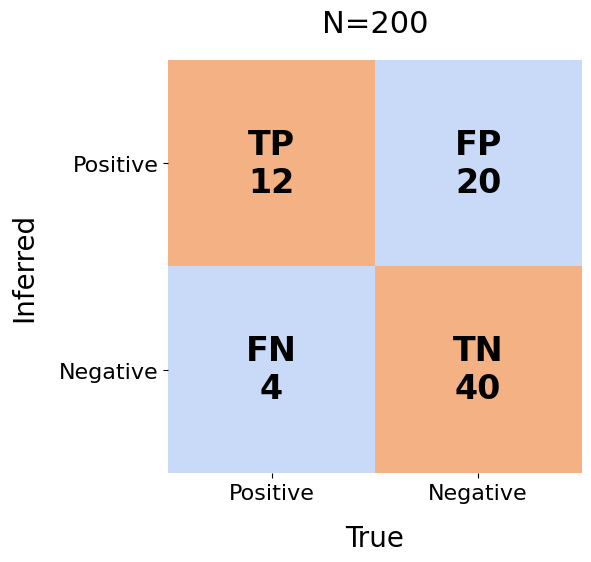

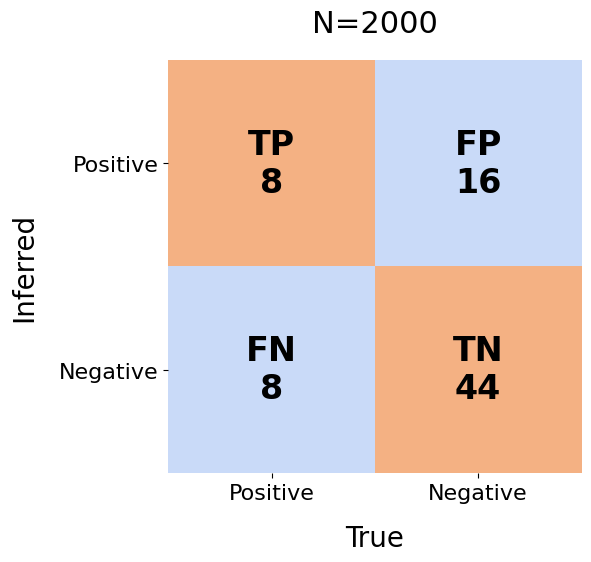

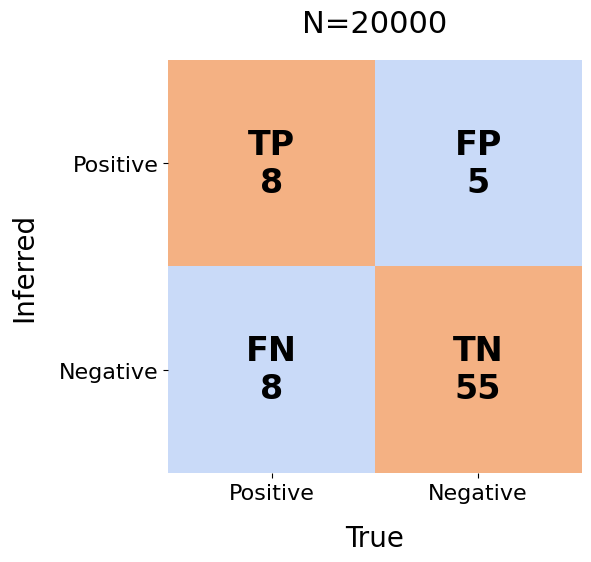

In [5]:
for N, df in metrics.items():
    TN = int(df["TN"].iloc[0])
    FP = int(df["FP"].iloc[0])
    FN = int(df["FN"].iloc[0])
    TP = int(df["TP"].iloc[0])

    plot_confusion_matrix(TN, FP, FN, TP, title=f"N={N}")


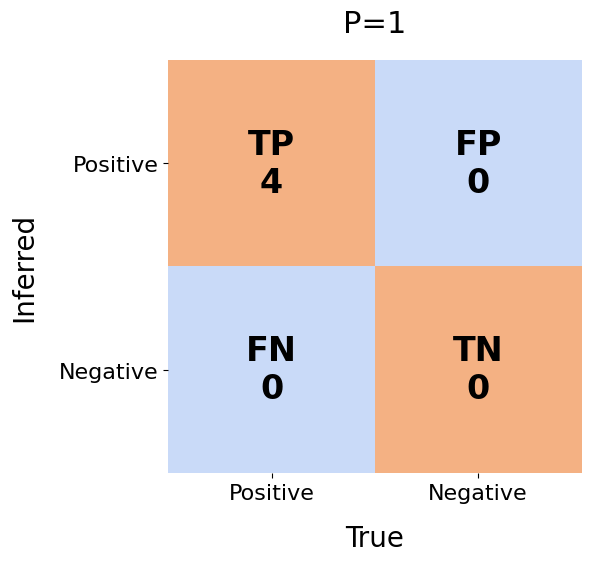

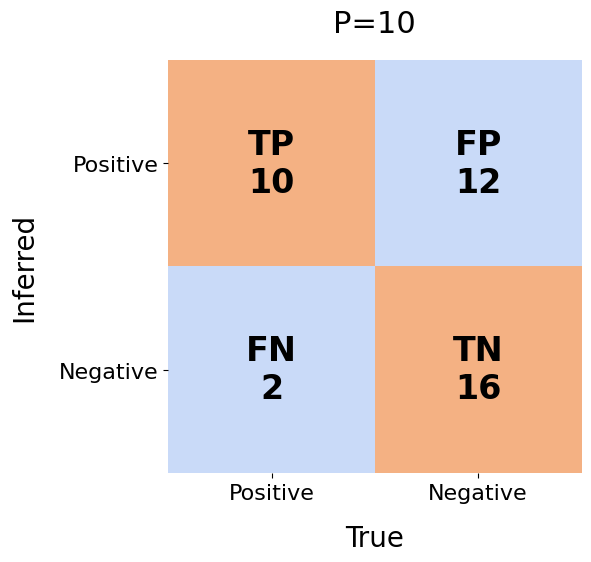

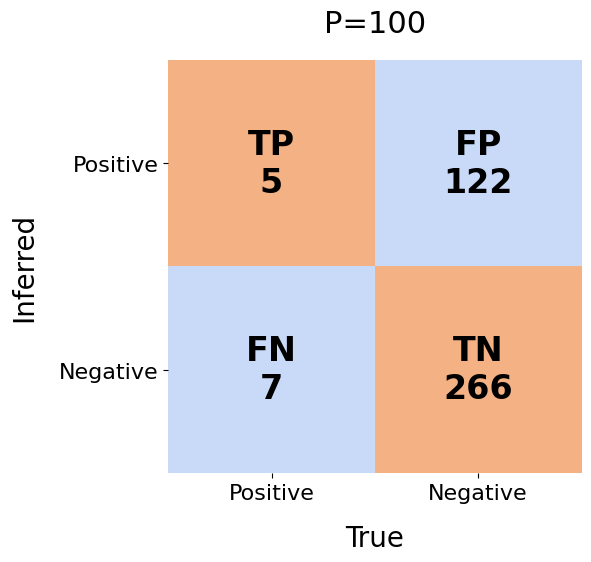

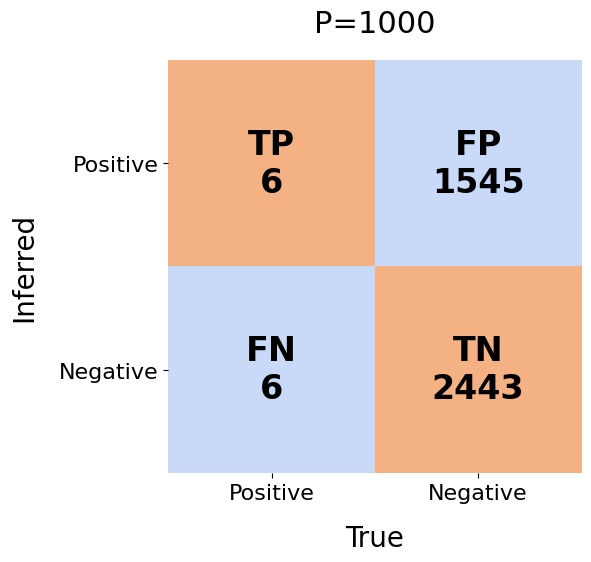

In [6]:
covariate_files = glob.glob("/users/ebrown62/scCODA/sccoda/datasets/results/covariate_scaling/metrics/driver_metricsP*")
covariate_metrics = {}
for f in covariate_files:
    P = int(re.search(r"driver_metricsP(\d+)", f).group(1))
    covariate_metrics[P] = pd.read_csv(f)
    
for P, df in covariate_metrics.items():
    TN = int(df["TN"].iloc[0])
    FP = int(df["FP"].iloc[0])
    FN = int(df["FN"].iloc[0])
    TP = int(df["TP"].iloc[0])

    plot_confusion_matrix(TN, FP, FN, TP, title=f"P={P}")


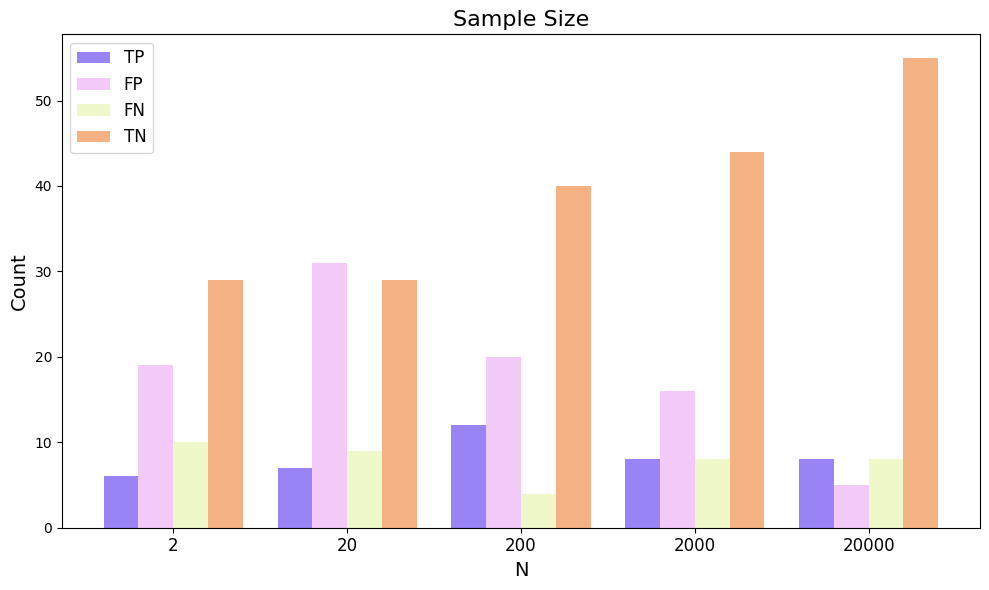

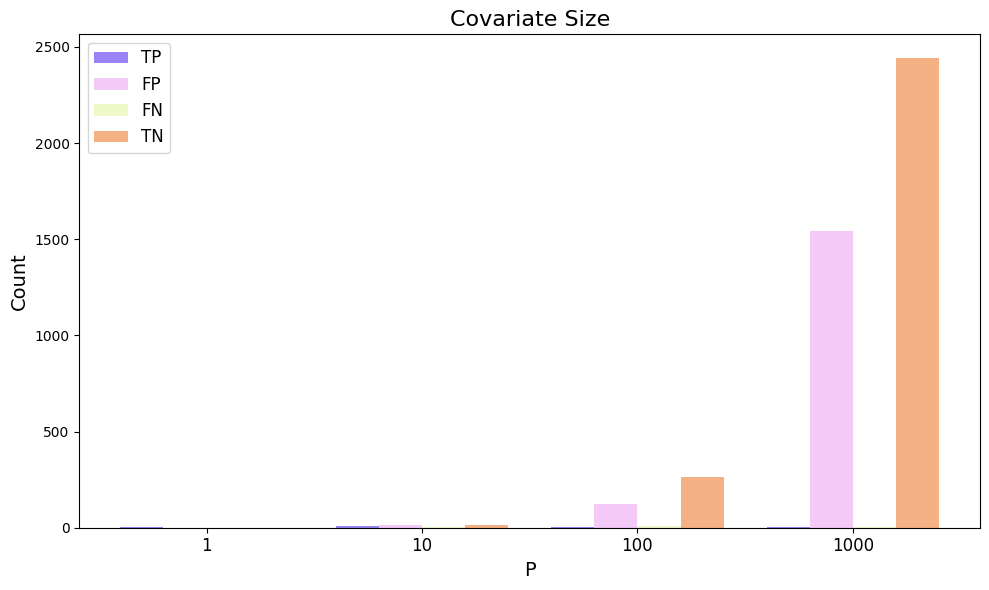

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def barplot_confusion_counts(metrics, title, xlabel="N"):
    
    Ns = sorted(metrics.keys())
    TP = [int(metrics[N]["TP"].iloc[0]) for N in Ns]
    FP = [int(metrics[N]["FP"].iloc[0]) for N in Ns]
    FN = [int(metrics[N]["FN"].iloc[0]) for N in Ns]
    TN = [int(metrics[N]["TN"].iloc[0]) for N in Ns]

    bar_width = 0.2
    x = np.arange(len(Ns))

    plt.figure(figsize=(10,6))

    plt.bar(x - 1.5*bar_width, TP, width=bar_width, label="TP", color="#9a83f4")
    plt.bar(x - 0.5*bar_width, FP, width=bar_width, label="FP", color="#f3c9f8")
    plt.bar(x + 0.5*bar_width, FN, width=bar_width, label="FN", color="#eef8c9")
    plt.bar(x + 1.5*bar_width, TN, width=bar_width, label="TN", color="#f4b183")

    plt.xticks(x, Ns, fontsize=12)
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=12)

    plt.tight_layout()
    plt.show()

barplot_confusion_counts(metrics, title="Sample Size", xlabel="N")
barplot_confusion_counts(covariate_metrics, title="Covariate Size", xlabel="P")

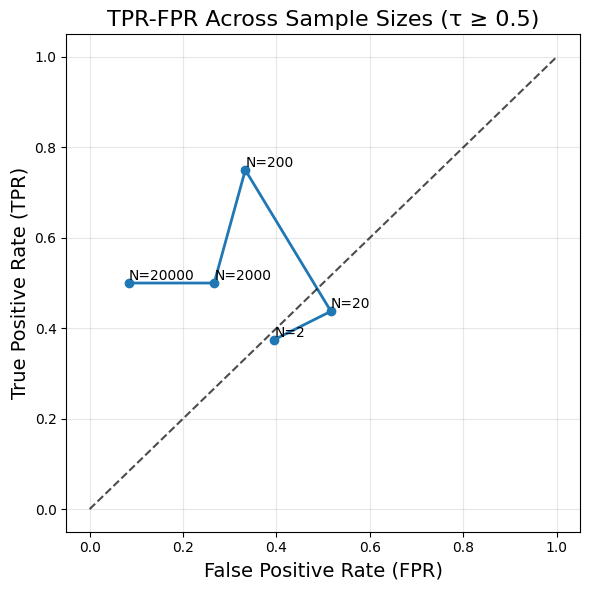

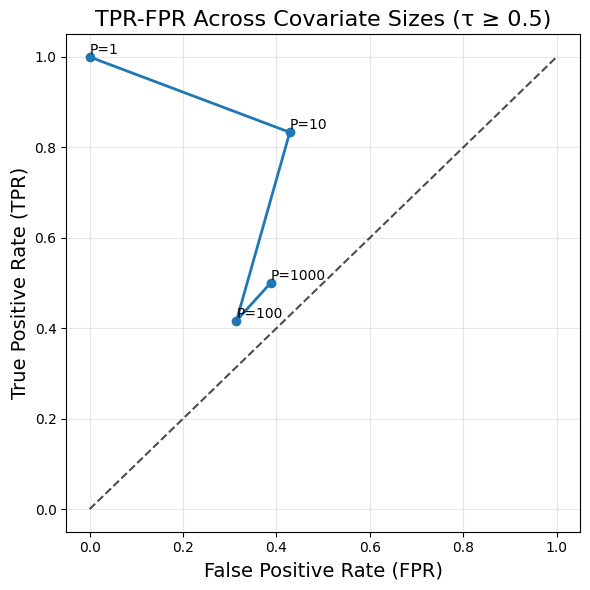

In [14]:
def plot_roc_from_confusions(metrics, title="TPR-FPR Across Sample Sizes (τ ≥ 0.5)", type="N"):
    Ns = sorted(metrics.keys())

    TPR = []
    FPR = []

    for N in Ns:
        df = metrics[N]
        TP = int(df["TP"].iloc[0])
        FP = int(df["FP"].iloc[0])
        FN = int(df["FN"].iloc[0])
        TN = int(df["TN"].iloc[0])

        tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
        fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
        
        TPR.append(tpr)
        FPR.append(fpr)

    plt.figure(figsize=(6,6))

    plt.plot(FPR, TPR, marker="o", linewidth=2)
    for fpr, tpr, N in zip(FPR, TPR, Ns):
        plt.text(fpr, tpr, f"{type}={N}", fontsize=10, ha="left", va="bottom")

    plt.plot([0,1], [0,1], 'k--', alpha=0.7)

    plt.xlabel("False Positive Rate (FPR)", fontsize=14)
    plt.ylabel("True Positive Rate (TPR)", fontsize=14)
    plt.title(title, fontsize=16)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_roc_from_confusions(metrics, title="TPR-FPR Across Sample Sizes (τ ≥ 0.5)", type="N")
plot_roc_from_confusions(covariate_metrics, title="TPR-FPR Across Covariate Sizes (τ ≥ 0.5)", type="P")